In [59]:
#IMPORTING LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
#DATA LOADING
url="https://raw.githubusercontent.com/nivetha486/24ADI204_DSV_Team12/refs/heads/main/Cleaned_Autoimmune_Disorder_Dataset%20(2).csv"
df = pd.read_csv(url)
display(df.head())

,Patient_ID,Age,Gender,Diagnosis,Sickness_Duration_Months,RBC_Count,Hemoglobin,Hematocrit,MCV,MCH,...,C1_inhibitor,Anti_TIF1,Anti_epidermal_basement_membrane_IgA,Anti_OmpC,pANCA,Anti_tissue_transglutaminase,anti_Scl_70,Anti_Mi2,Anti_parietal_cell,Progesterone_antibodies
0,1,65,Female,Linear IgA disease,26,3.54,13.18,44.35,99.85,31.80,...,0,0,1,0,0,0,0,0,0,0
1,2,61,Male,Dermatomyositis,106,4.97,14.73,42.39,94.86,29.94,...,0,1,0,0,0,0,0,1,0,0
2,3,42,Male,Ord's thyroiditis,6,3.91,13.66,42.41,88.26,29.43,...,0,0,0,0,0,0,0,0,0,0
3,4,45,Female,Restless legs syndrome,11,4.57,14.96,40.10,85.95,27.42,...,0,0,0,0,0,0,0,0,0,0
4,5,78,Female,Autoimmune polyendocrine syndrome type 2 (APS2),30,4.88,11.21,37.58,93.16,29.87,...,0,0,0,0,0,0,0,0,0,0


In [61]:
df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 76 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Patient_ID                            12500 non-null  int64  
 1   Age                                   12500 non-null  int64  
 2   Gender                                12500 non-null  object 
 3   Diagnosis                             12500 non-null  object 
 4   Sickness_Duration_Months              12500 non-null  int64  
 5   RBC_Count                             12500 non-null  float64
 6   Hemoglobin                            12500 non-null  float64
 7   Hematocrit                            12500 non-null  float64
 8   MCV                                   12500 non-null  float64
 9   MCH                                   12500 non-null  float64
 10  MCHC                                  12500 non-null  float64
 11  RDW            

In [62]:
#bivariate analysis


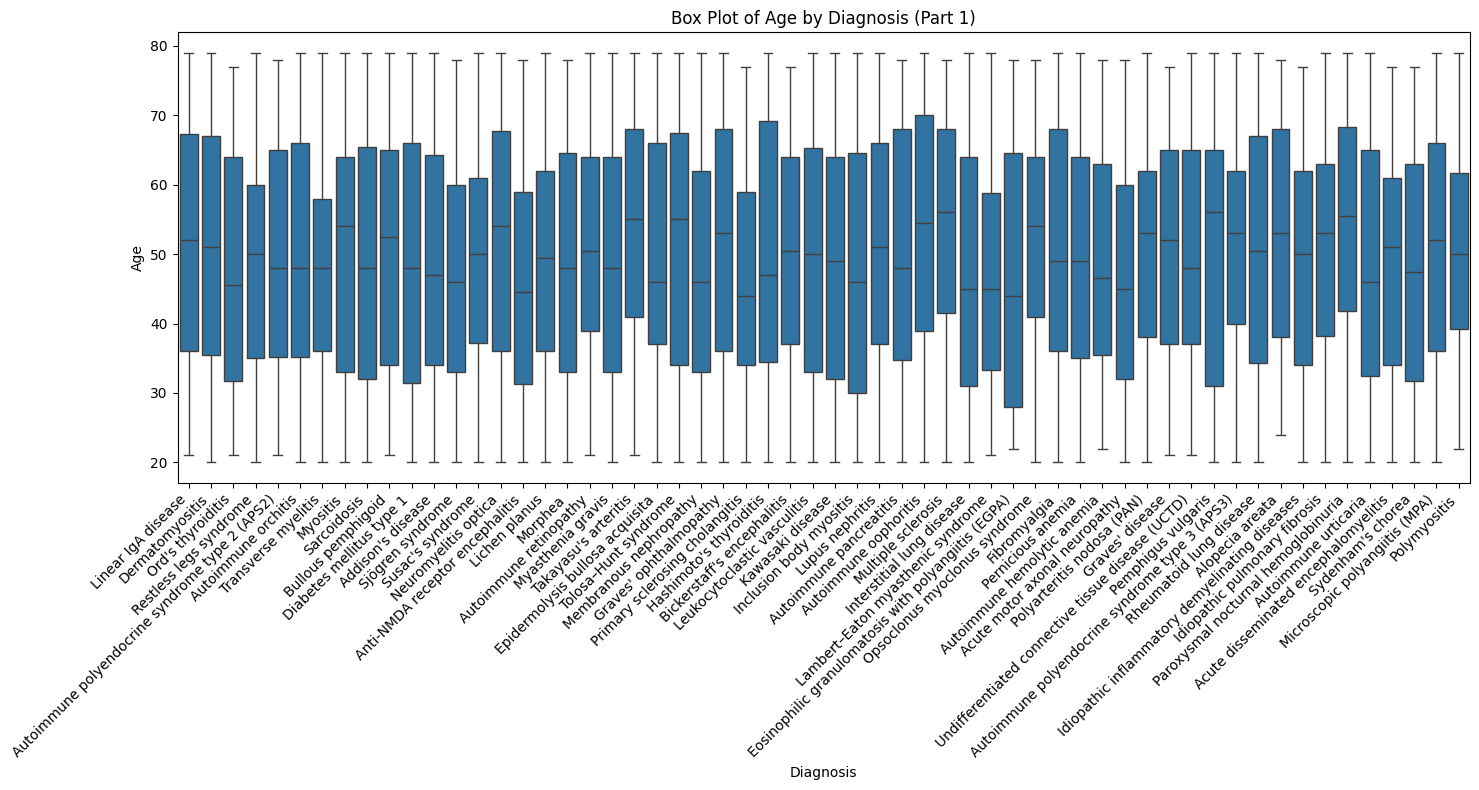

In [63]:
unique_diagnoses = df['Diagnosis'].unique()
num_diagnoses = len(unique_diagnoses)
half_point = num_diagnoses // 2

dr_diagnoses_1 = unique_diagnoses[:half_point]
dr_diagnoses_2 = unique_diagnoses[half_point:]

df_filtered_1 = df[df['Diagnosis'].isin(dr_diagnoses_1)]
df_filtered_2 = df[df['Diagnosis'].isin(dr_diagnoses_2)]

plt.figure(figsize=(15, 8))
sns.boxplot(x='Diagnosis', y='Age', data=df_filtered_1)
plt.title('Box Plot of Age by Diagnosis (Part 1)')
plt.xlabel('Diagnosis')
plt.ylabel('Age')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

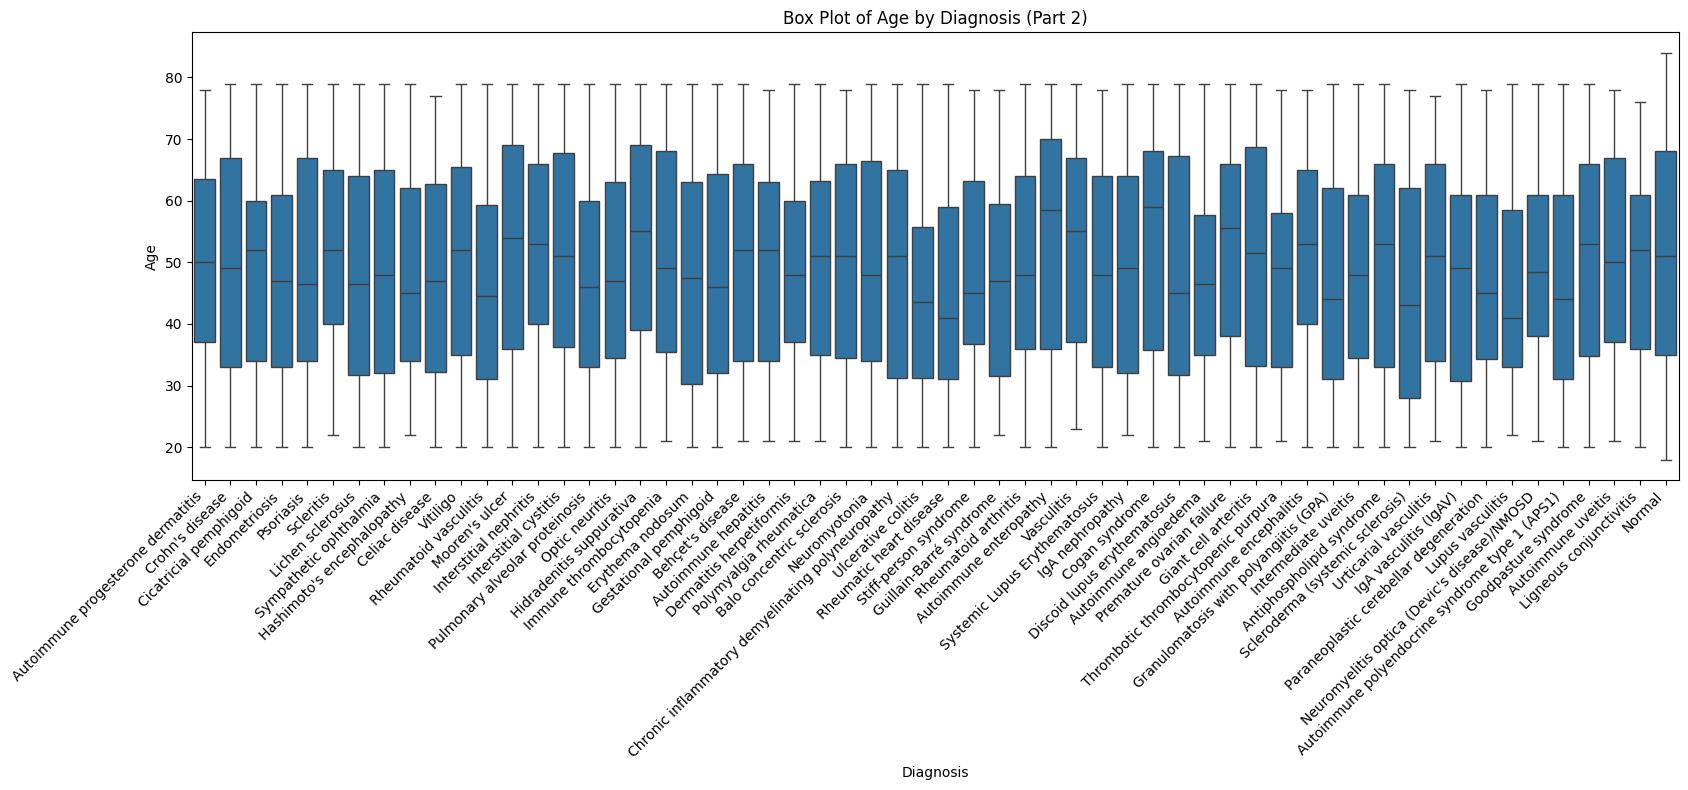

In [64]:
plt.figure(figsize=(17, 8))
sns.boxplot(x='Diagnosis', y='Age', data=df_filtered_2)
plt.title('Box Plot of Age by Diagnosis (Part 2)')
plt.xlabel('Diagnosis')
plt.ylabel('Age')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

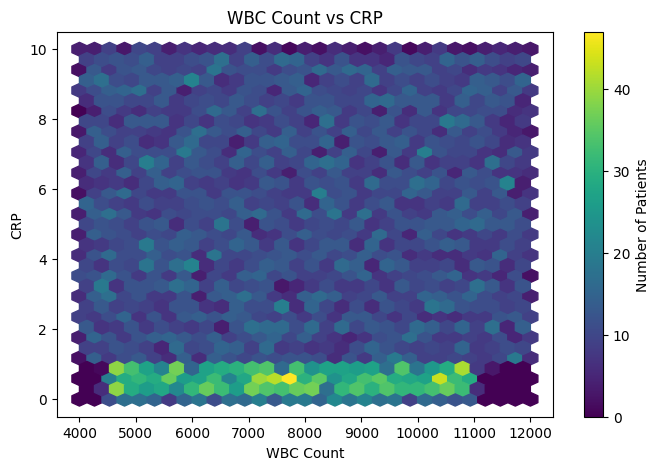

In [75]:
plt.figure(figsize=(8, 5))

plt.hexbin(df['WBC_Count'], df['CRP'], gridsize=30)

plt.xlabel('WBC Count')
plt.ylabel('CRP')
plt.title('WBC Count vs CRP')

plt.colorbar(label='Number of Patients')
plt.show()

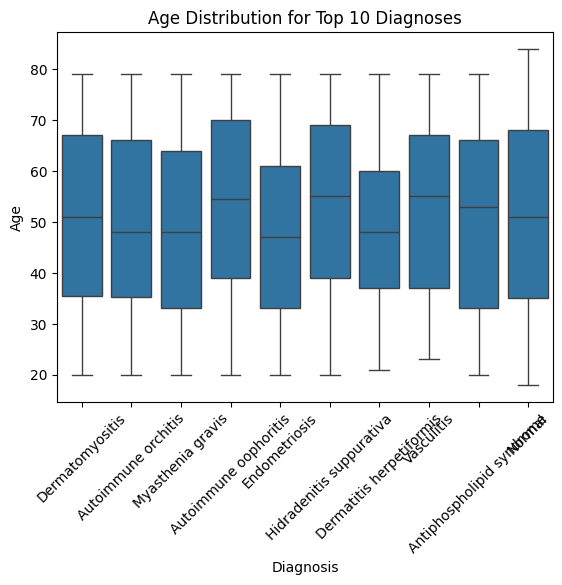

In [86]:
top_diagnoses = df['Diagnosis'].value_counts().head(10).index

df_top = df[df['Diagnosis'].isin(top_diagnoses)]

sns.boxplot(x='Diagnosis', y='Age', data=df_top)

plt.xticks(rotation=45)
plt.title('Age Distribution for Top 10 Diagnoses')
plt.show()

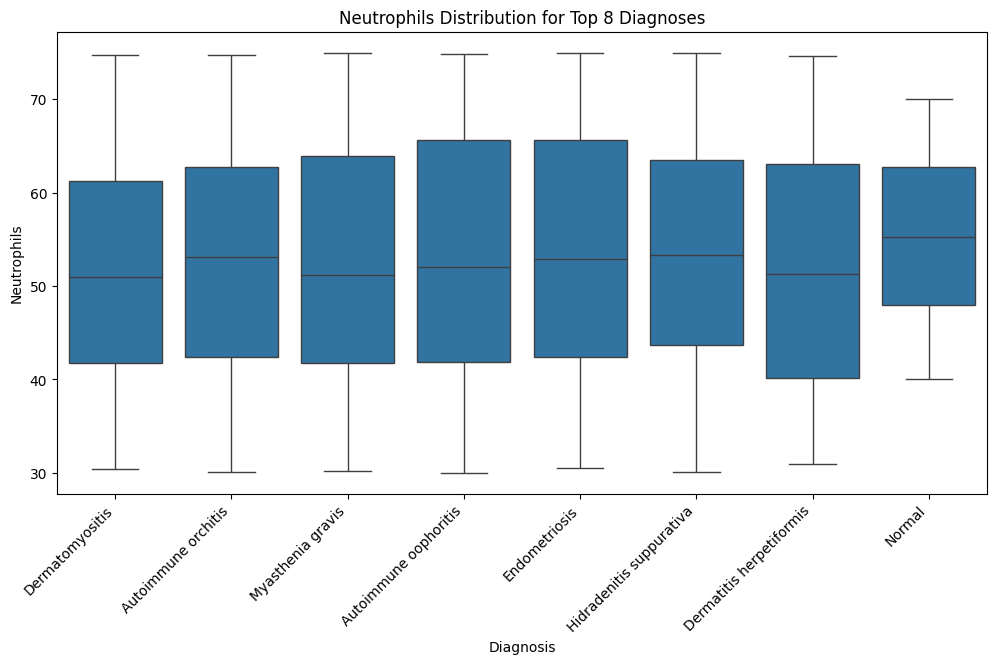

In [98]:
top_diagnoses = df['Diagnosis'].value_counts().head(8).index

df_top = df[df['Diagnosis'].isin(top_diagnoses)]

plt.figure(figsize=(12, 6))

sns.boxplot(
    x='Diagnosis',
    y='Neutrophils',
    data=df_top
)

plt.xlabel('Diagnosis')
plt.ylabel('Neutrophils')
plt.title('Neutrophils Distribution for Top 8 Diagnoses')

plt.xticks(rotation=45, ha='right')

plt.show()

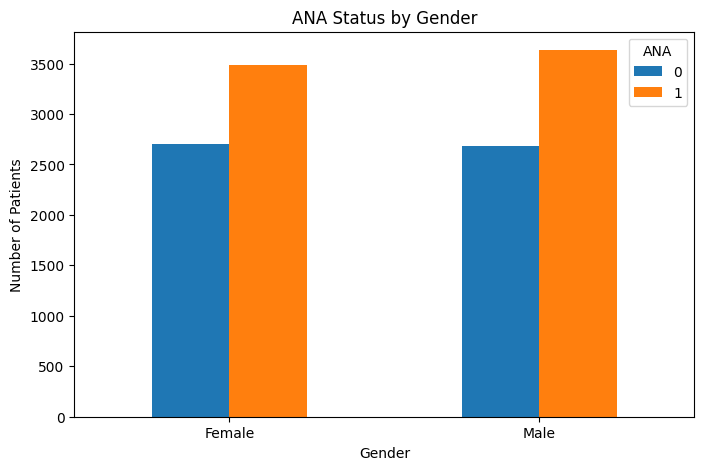

In [99]:
gender_ana = pd.crosstab(df['Gender'], df['ANA'])

gender_ana.plot(kind='bar', figsize=(8, 5))

plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.title('ANA Status by Gender')

plt.xticks(rotation=0)
plt.legend(title='ANA')

plt.show()

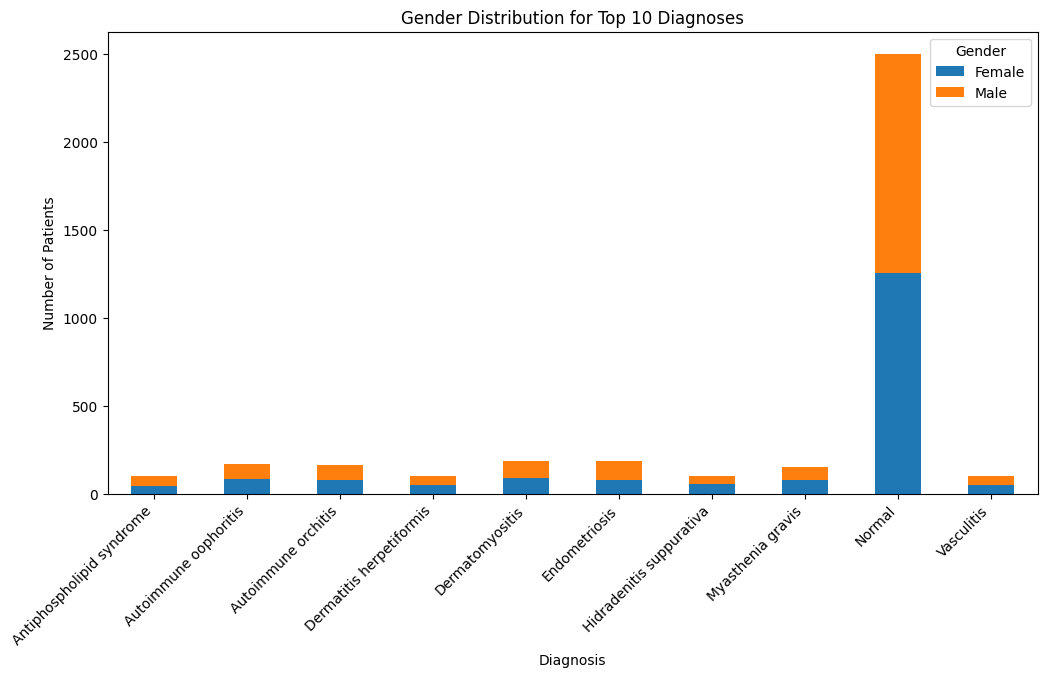

In [83]:
top_diagnoses = df['Diagnosis'].value_counts().head(10).index

df_top = df[df['Diagnosis'].isin(top_diagnoses)]

gender_diagnosis = pd.crosstab(
    df_top['Diagnosis'],
    df_top['Gender']
)

gender_diagnosis.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')
plt.title('Gender Distribution for Top 10 Diagnoses')

plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')

plt.show()

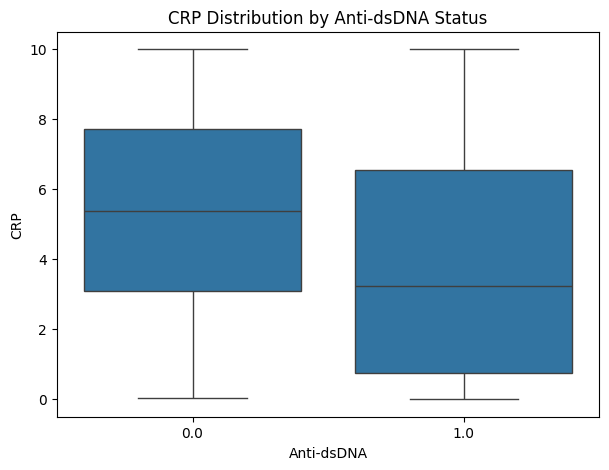

In [84]:
plt.figure(figsize=(7, 5))

sns.boxplot(x='Anti-dsDNA', y='CRP', data=df)

plt.xlabel('Anti-dsDNA')
plt.ylabel('CRP')
plt.title('CRP Distribution by Anti-dsDNA Status')

plt.show()

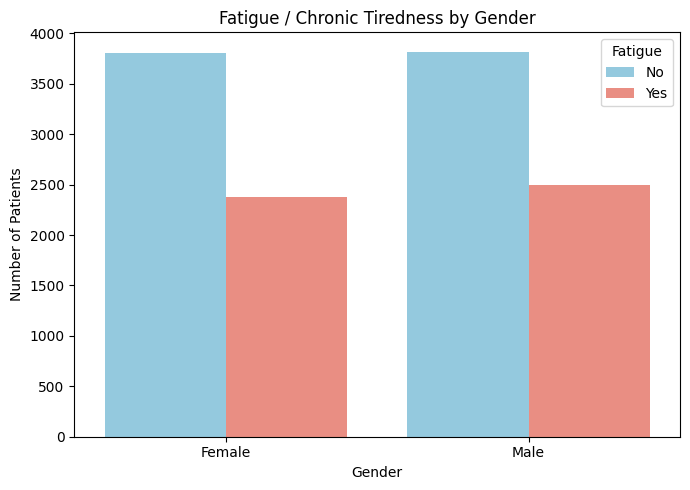

In [82]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x="Gender",
    hue="Fatigue or chronic tiredness",
    palette=["skyblue", "salmon"]
)

plt.title("Fatigue / Chronic Tiredness by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.legend(title="Fatigue", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

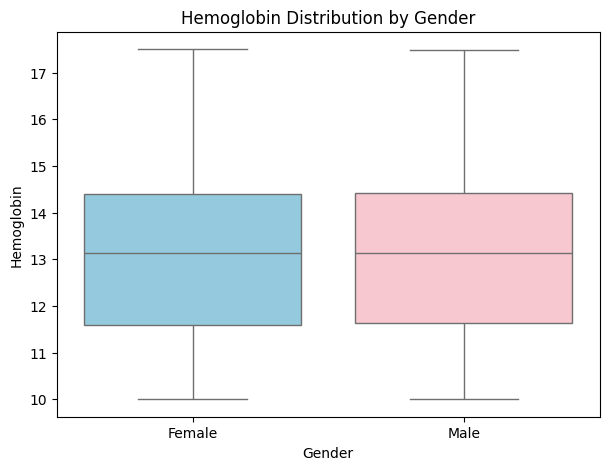

In [104]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x='Gender',
    y='Hemoglobin',
    hue='Gender',
    data=df,
    palette=['skyblue', 'pink'],
    legend=False
)

plt.xlabel('Gender')
plt.ylabel('Hemoglobin')
plt.title('Hemoglobin Distribution by Gender')

plt.show()

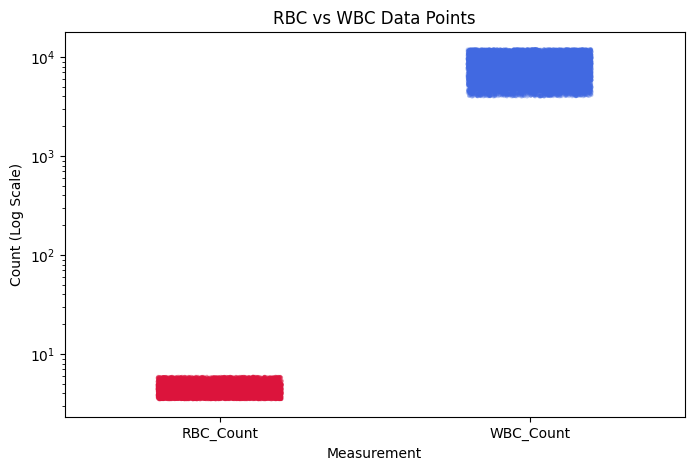

In [105]:
df_melted = df.melt(
    value_vars=["RBC_Count", "WBC_Count"],
    var_name="Measurement",
    value_name="Value",
)

# 2. Plot the strip plot with distinct colors without warnings
plt.figure(figsize=(8, 5))
sns.stripplot(
    data=df_melted,
    x="Measurement",
    y="Value",
    hue="Measurement",
    palette={"RBC_Count": "crimson", "WBC_Count": "royalblue"},
    alpha=0.3,
    jitter=0.2,
    size=3,
    legend=False,
)

plt.yscale("log")  # Log scale keeps both ranges clearly visible
plt.title("RBC vs WBC Data Points")
plt.ylabel("Count (Log Scale)")
plt.show()

/tmp/ipykernel_3447/3264577756.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


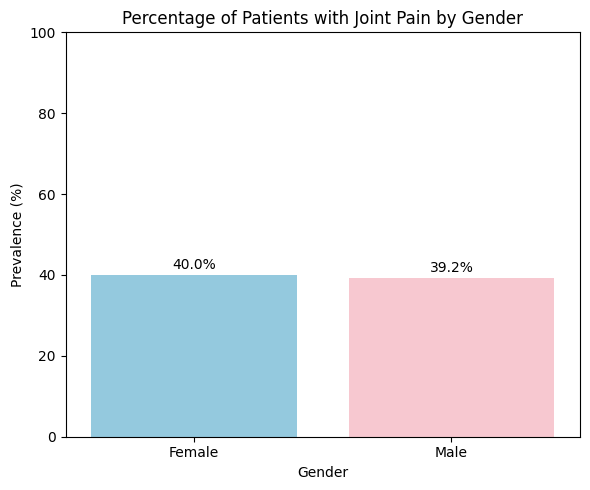

In [106]:
# Calculate percentage of joint pain by gender
joint_gender_pct = (
    df.groupby("Gender")["Joint pain"]
    .mean()
    .reset_index()
)
joint_gender_pct["Percentage"] = joint_gender_pct["Joint pain"] * 100

plt.figure(figsize=(6, 5))
sns.barplot(
    data=joint_gender_pct,
    x="Gender",
    y="Percentage",
    palette=["skyblue", "pink"]
)

plt.title("Percentage of Patients with Joint Pain by Gender")
plt.xlabel("Gender")
plt.ylabel("Prevalence (%)")
plt.ylim(0, 100)

# Add value labels above the bars
for index, row in joint_gender_pct.iterrows():
    plt.text(index, row["Percentage"] + 1.5, f"{row['Percentage']:.1f}%", ha='center')

plt.tight_layout()
plt.show()

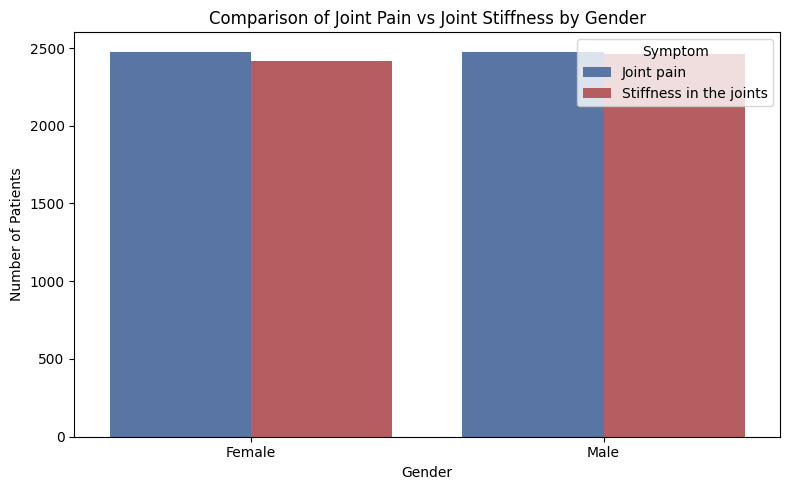

In [107]:
# Reshape data for Joint Pain and Joint Stiffness by Gender
joint_gender = (
    df.groupby("Gender")[["Joint pain", "Stiffness in the joints"]]
    .sum()
    .reset_index()
    .melt(id_vars="Gender", var_name="Symptom", value_name="Patient Count")
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=joint_gender,
    x="Gender",
    y="Patient Count",
    hue="Symptom",
    palette=["#4C72B0", "#C44E52"],
)

plt.title("Comparison of Joint Pain vs Joint Stiffness by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.legend(title="Symptom")
plt.tight_layout()
plt.show()

MULTIVARIATE ANALYSIS

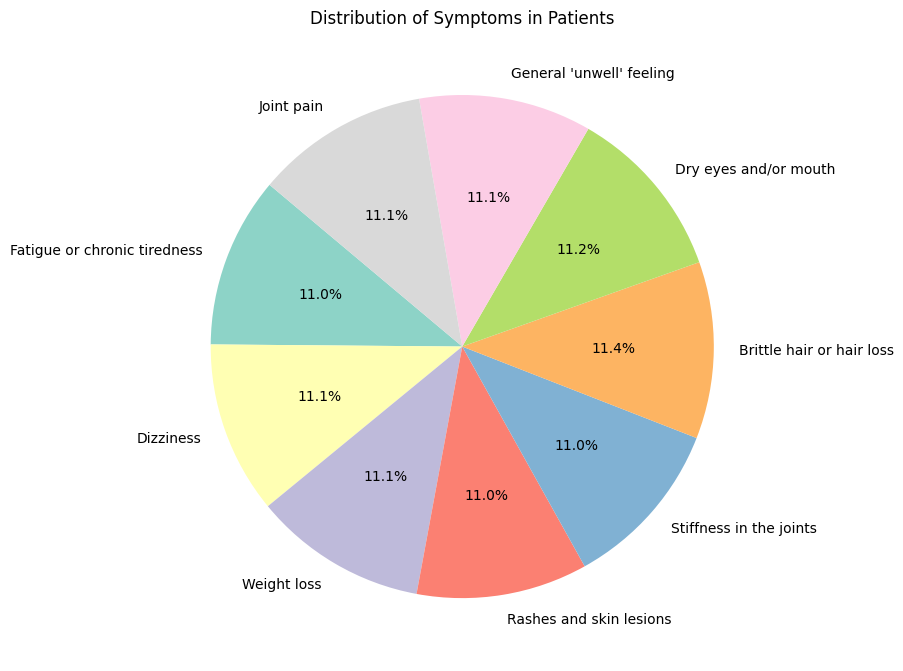

In [108]:
symptom_cols = [
    "Fatigue or chronic tiredness",
    "Dizziness",
    "Weight loss",
    "Rashes and skin lesions",
    "Stiffness in the joints",
    "Brittle hair or hair loss",
    "Dry eyes and/or mouth",
    "General 'unwell' feeling",
    "Joint pain",
]

# Calculate total cases (sum of 1s) for each symptom
symptom_counts = df[symptom_cols].sum()

# Plot the pie chart
plt.figure(figsize=(9, 9))
plt.pie(
    symptom_counts,
    labels=symptom_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=plt.cm.Set3.colors,
)

plt.title("Distribution of Symptoms in Patients")
plt.tight_layout()
plt.show()

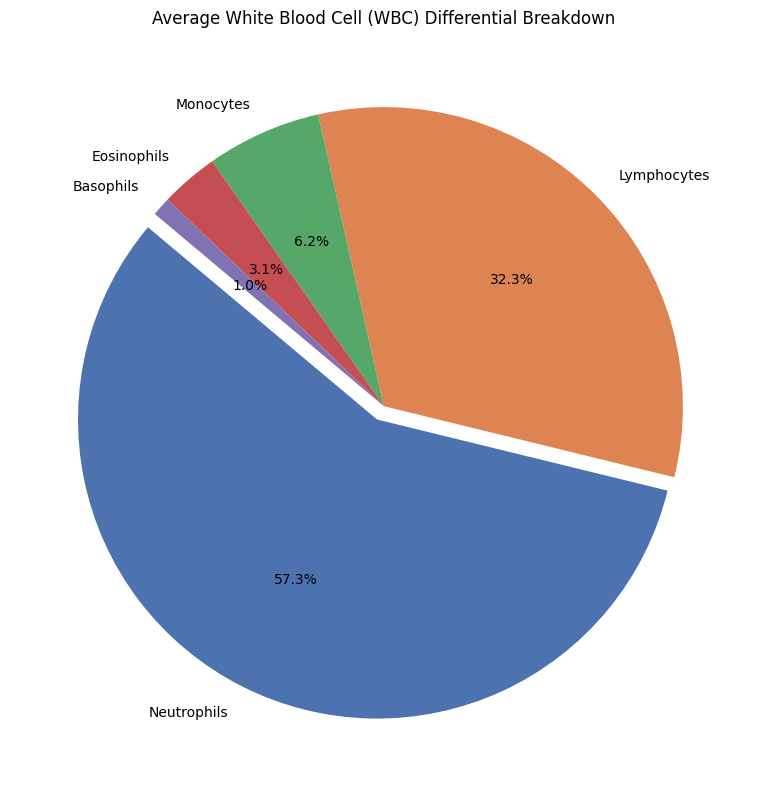

In [109]:
# Pie chart
wbc_cols = ["Neutrophils", "Lymphocytes", "Monocytes", "Eosinophils", "Basophils"]

# Calculate the mean percentage/value across all patients
wbc_means = df[wbc_cols].mean()

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    wbc_means,
    labels=wbc_means.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"],
    explode=(0.05, 0, 0, 0, 0),  # Slightly highlight the primary type (Neutrophils)
)

plt.title("Average White Blood Cell (WBC) Differential Breakdown")
plt.tight_layout()
plt.show()

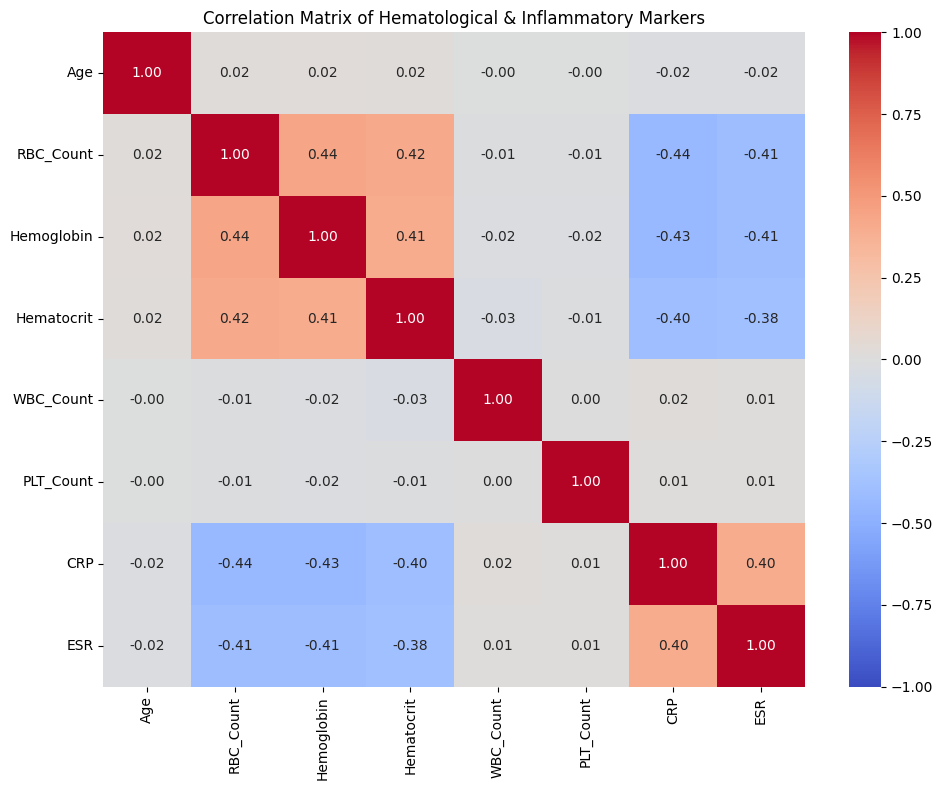

In [92]:
# Correlation Heatmap
num_cols = [
    "Age",
    "RBC_Count",
    "Hemoglobin",
    "Hematocrit",
    "WBC_Count",
    "PLT_Count",
    "CRP",
    "ESR",
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Hematological & Inflammatory Markers")
plt.tight_layout()
plt.show()

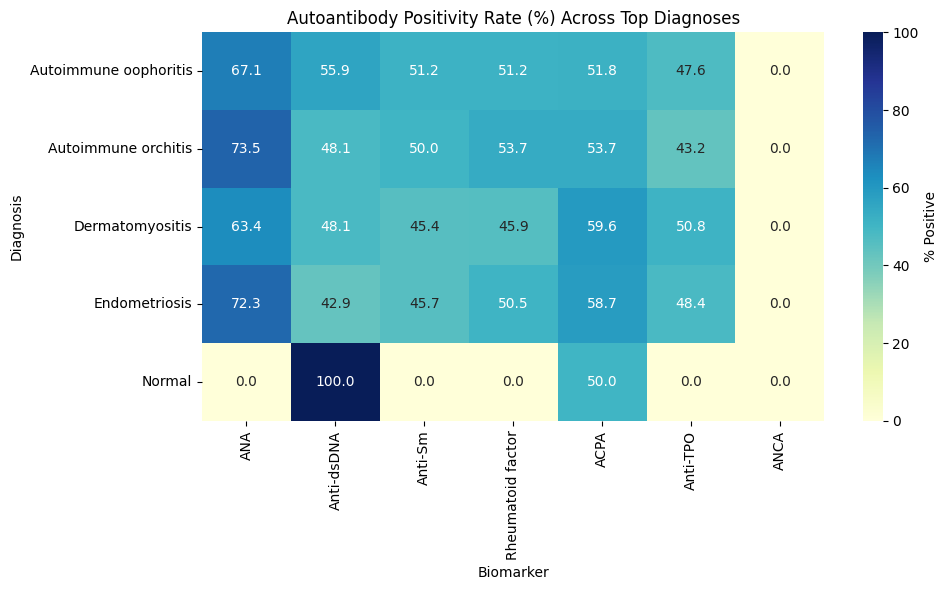

In [93]:
# Top 5 Diagnoses vs Autoantibody positivity rates
top_5_diag = df["Diagnosis"].value_counts().head(5).index
antibody_cols = [
    "ANA",
    "Anti-dsDNA",
    "Anti-Sm",
    "Rheumatoid factor",
    "ACPA",
    "Anti-TPO",
    "ANCA",
]

heatmap_data = (
    df[df["Diagnosis"].isin(top_5_diag)].groupby("Diagnosis")[antibody_cols].mean() * 100
)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "% Positive"})
plt.title("Autoantibody Positivity Rate (%) Across Top Diagnoses")
plt.xlabel("Biomarker")
plt.ylabel("Diagnosis")
plt.tight_layout()
plt.show()

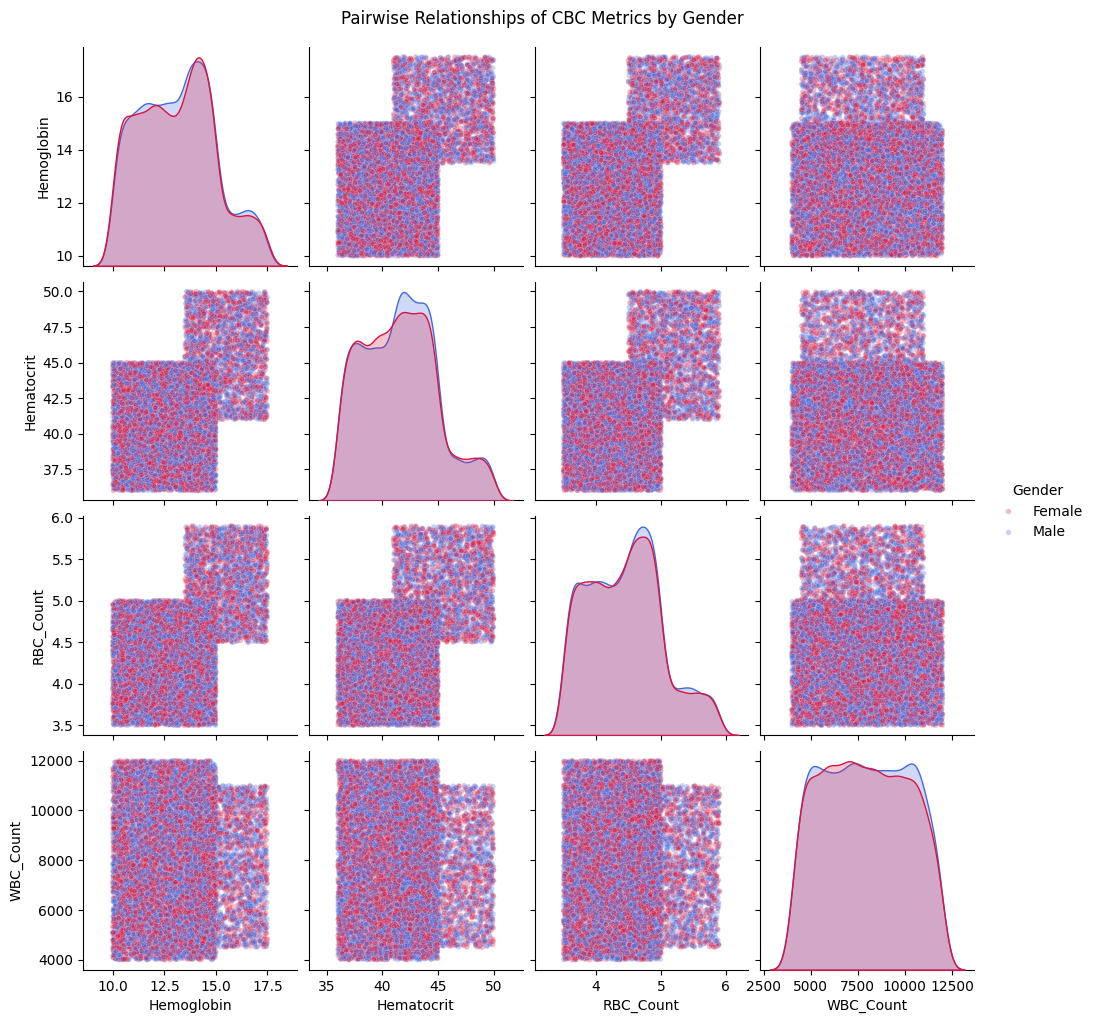

In [94]:
#Pairplot
sns.pairplot(
    data=df[["Hemoglobin", "Hematocrit", "RBC_Count", "WBC_Count", "Gender"]],
    hue="Gender",
    palette={"Male": "royalblue", "Female": "crimson"},
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 15},
)
plt.suptitle("Pairwise Relationships of CBC Metrics by Gender", y=1.02)
plt.show()

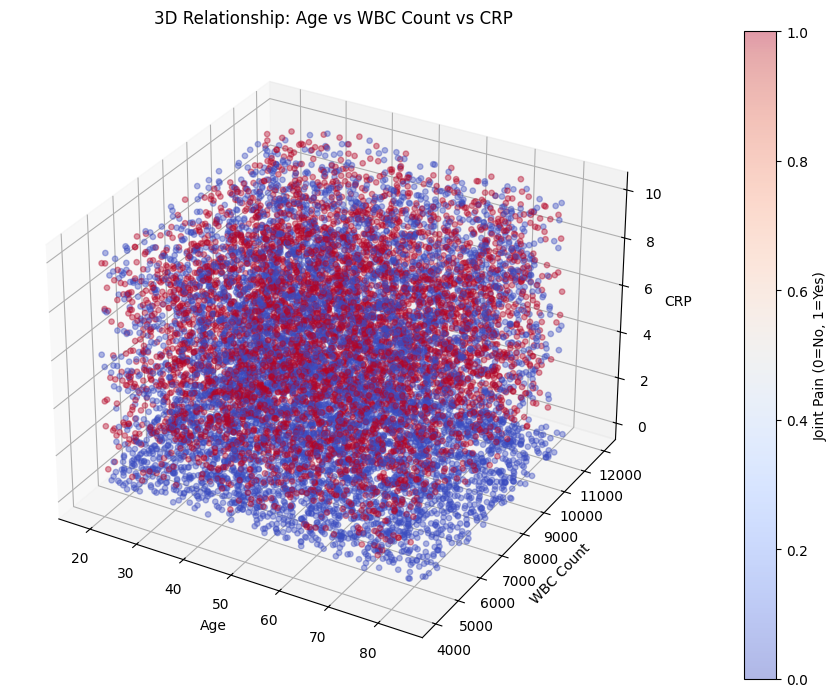

In [97]:
#3D scatterplot
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["Age"],
    df["WBC_Count"],
    df["CRP"],
    c=df["Joint pain"],
    cmap="coolwarm",
    alpha=0.4,
    s=15,
)

ax.set_xlabel("Age")
ax.set_ylabel("WBC Count")
ax.set_zlabel("CRP")
ax.set_title("3D Relationship: Age vs WBC Count vs CRP")

cbar = plt.colorbar(scatter, pad=0.1)
cbar.set_label("Joint Pain (0=No, 1=Yes)")

plt.tight_layout()
plt.show()